In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.2750,NaN,S
451,452,0,3,"Hagland, Mr. Ingvald Olai Olsen",male,NaN,1,0,65303,19.9667,NaN,S
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
668,669,0,3,"Cook, Mr. Jacob",male,43.0,0,0,A/5 3536,8.0500,NaN,S
726,727,1,2,"Renouf, Mrs. Peter Henry (Lillian Jefferys)",female,30.0,3,0,31027,21.0000,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0000,NaN,S
463,464,0,2,"Milling, Mr. Jacob Christian",male,48.0,0,0,234360,13.0000,NaN,S
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S
404,405,0,3,"Oreskovic, Miss. Marija",female,20.0,0,0,315096,8.6625,NaN,S
799,800,0,3,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S


Text(0.5, 1.0, 'Correlation Heatmap')

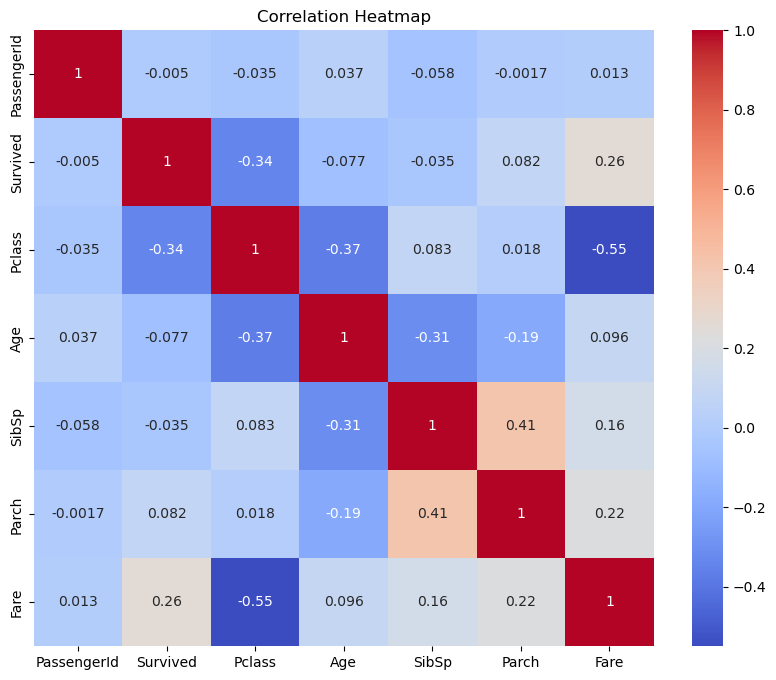

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'Missing Data Map')

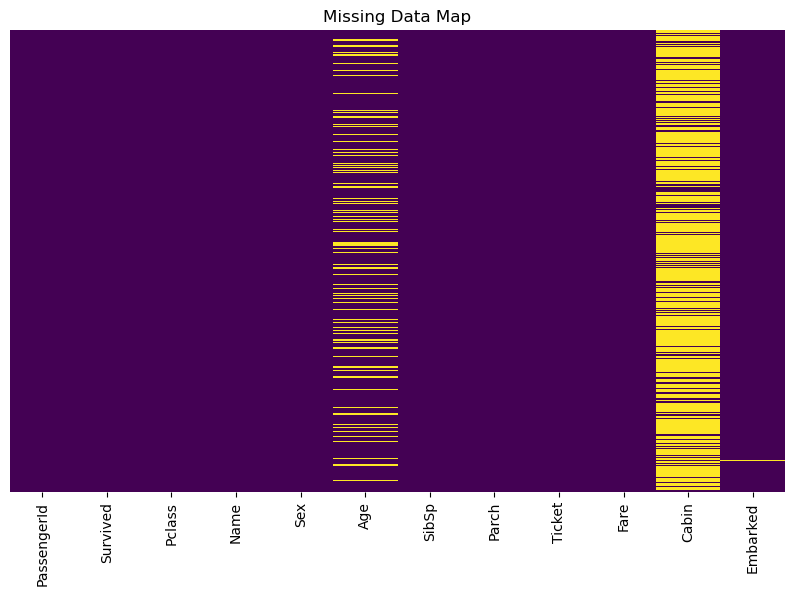

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Map')

In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Text(0.5, 1.0, 'Target Variable: Survived Count')

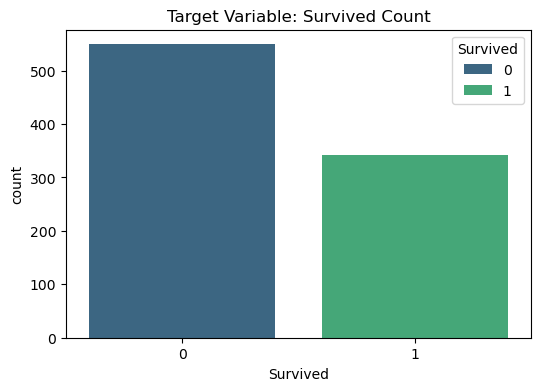

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis', hue=df['Survived'])
plt.title('Target Variable: Survived Count')

Text(0.5, 1.0, 'Gender Distribution')

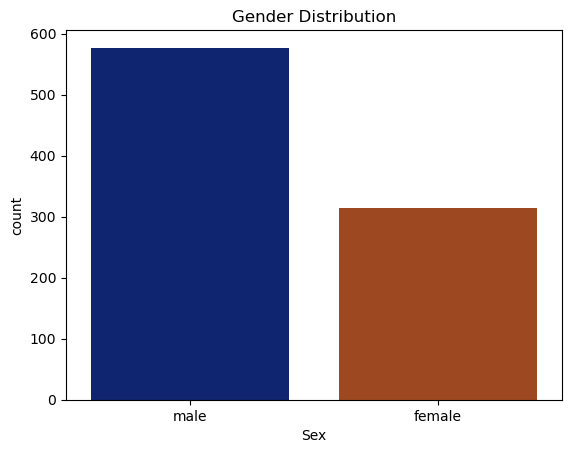

In [29]:
sns.countplot(x='Sex', data=df, palette='dark', hue=df['Sex'])
plt.title('Gender Distribution')

Text(0.5, 1.0, ' Age Distribution')

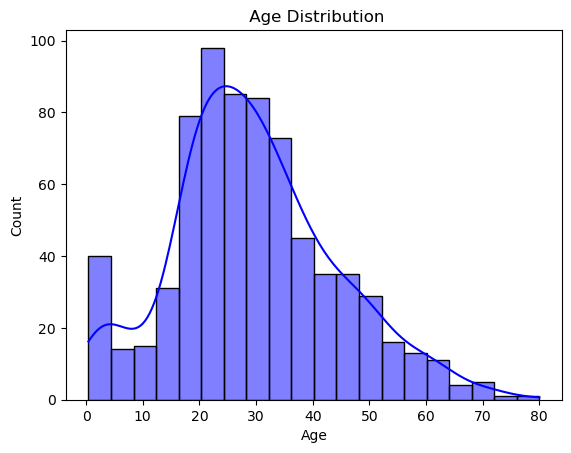

In [30]:
sns.histplot(df['Age'].dropna(), kde=True, color='blue')
plt.title(' Age Distribution')

Text(0.5, 1.0, 'Survival Rate by Gender')

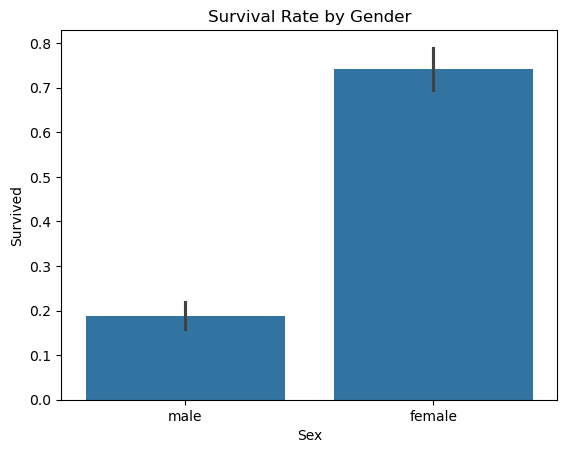

In [31]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')

Text(0.5, 1.0, 'Survival Rate by Class')

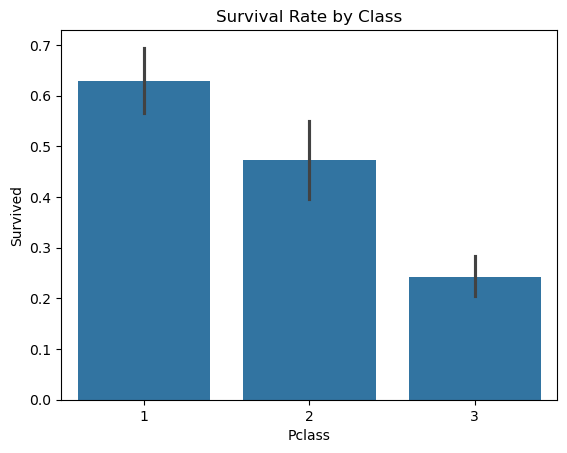

In [32]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')

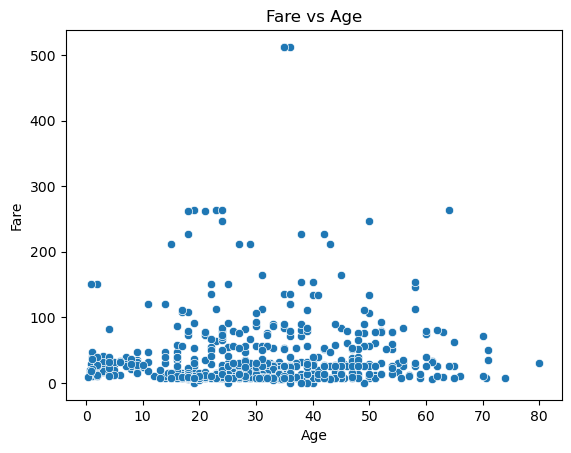

In [40]:
sns.scatterplot(data=df,x='Age',y='Fare')
plt.title("Fare vs Age")
plt.show()

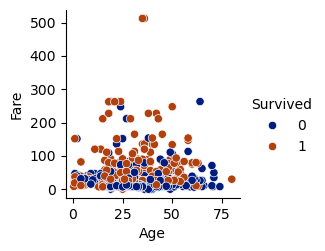

In [49]:
sns.pairplot(data=df, hue='Survived',palette='dark',x_vars='Age',y_vars='Fare')

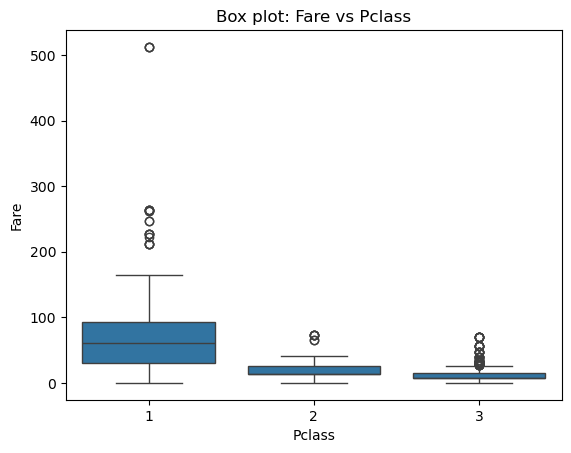

In [56]:
sns.boxplot(data=df,x='Pclass', y='Fare')
plt.title("Box plot: Fare vs Pclass")
plt.show()

<Axes: xlabel='Age', ylabel='Fare'>

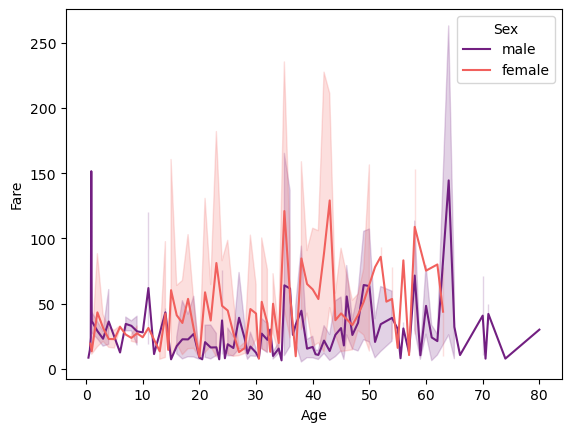

In [61]:
sns.lineplot(data=df, x='Age',y='Fare',hue='Sex',palette='magma')

In [63]:
df.head(
    
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


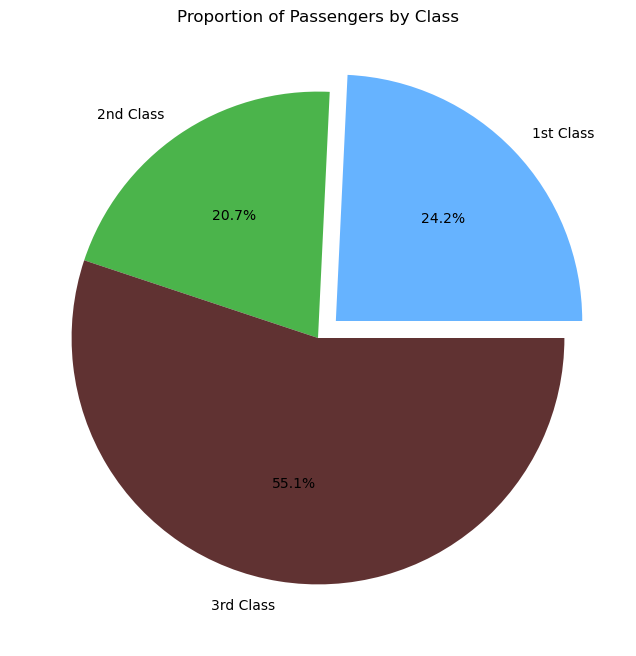

In [71]:
plt.figure(figsize=(8, 8))
class_counts = df['Pclass'].value_counts().sort_index()
labels = ['1st Class', '2nd Class', '3rd Class']
plt.pie(class_counts, 
        labels=labels, 
        autopct='%1.1f%%',     # Shows the percentage on the slice
        colors=['#66b3ff',"#4bb44b","#603232"], 
        explode=(0.1, 0, 0))   # "Pulls out" the 1st Class slice slightly

plt.title('Proportion of Passengers by Class')
plt.show()

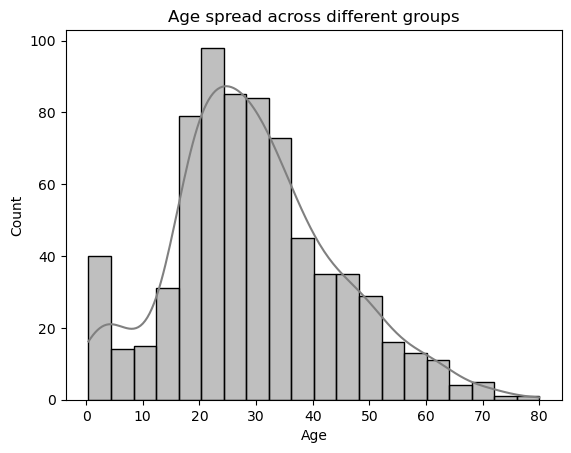

In [76]:
sns.histplot(data=df,x='Age',kde=True,color='gray')
plt.title("Age spread across different groups")
plt.show()

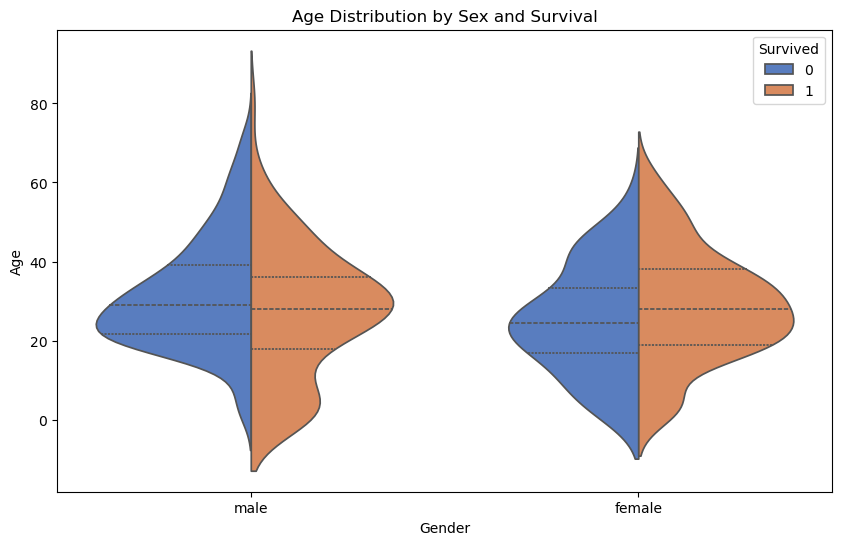

In [81]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Sex', y='Age', hue='Survived', 
               split=True, palette='muted', inner='quartile')


plt.title('Age Distribution by Sex and Survival')
plt.xlabel('Gender')
plt.ylabel('Age')

plt.show()